Data import and DataFrame generation

In [1]:
from pathlib import Path
import pandas as pd

path = Path() / "Dataset3_PortfolioReplicaStrategy.xlsx"

data = pd.read_excel(path)
data = data.set_index('Ticker')
data = data.sort_index()

data.head()

,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Ticker,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


Data preparation

In [2]:
index_components = {"MXWO" : 0.25,
                    "MXWD" : 0,
                    "LEGATRUU" : 0.25,
                    "HFRXGL" : 0.5}

component_returns = data[list(index_components.keys())].pct_change().dropna()

Y = sum(component_returns[col] * w for col, w in index_components.items())
Y.name = 'Monster_Index'

futures = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1', 'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

X = data[futures].pct_change().dropna() # Futures matrix

common_dates = X.index.intersection(Y.index) # Riallineo i dataset
X = X.loc[common_dates]
Y = Y.loc[common_dates]

Train-Test split and futures returnstest standardization


In [3]:
from sklearn.preprocessing import StandardScaler

split_date = '2018-12-31'

X_train = X.loc[:split_date]
X_test = X.loc[split_date:]
Y_train = Y.loc[:split_date]
Y_test = Y.loc[split_date:]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Implementazione modello OLS


In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression

rolling_window = 52

predicted_returns_train = []
weights_train = []
dates_train = []

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train.iloc[i : i + rolling_window]

    model = LinearRegression(fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_train.append(pred)
    weights_train.append(model.coef_)
    dates_train.append(Y_train.index[i + rolling_window])

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all = pd.concat([Y_train, Y_test])

predicted_returns_test = []
weights_test           = []
dates_test             = []

for j in range(len(X_train_scaled), len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all.iloc[j - rolling_window : j]

    model = LinearRegression(fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_all_scaled[j + 1].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_test.append(pred)
    weights_test.append(model.coef_)
    dates_test.append(Y_all.index[j + 1])

Y_pred_train = pd.Series(predicted_returns_train, index=dates_train)
Y_pred_test = pd.Series(predicted_returns_test, index=dates_test)

Metriche

In [5]:
def annual_return(returns):
    ann_ret = returns.mean() * 52
    return ann_ret

def volatility(returns):
    vol = np.std(returns, ddof=1) * np.sqrt(52)
    return vol

def tracking_error_volatility(returns_replica, returns_target):
    tev = np.std(returns_replica - returns_target, ddof=1) * np.sqrt(52)
    return tev

def sharpe_ratio(returns):
    sharpe = annual_return(returns) / volatility(returns)
    return sharpe

def max_drawdown(returns):
    cumulative  = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

def gross_exposure(weights_history):
    weights_df = pd.DataFrame(weights_history)
    return weights_df.abs().sum(axis=1).mean()

def correlation(returns_replica, returns_target):
    corr = returns_replica.corr(returns_target)
    return corr

def information_ratio(returns_replica, returns_target):
    active_returns = returns_replica - returns_target
    
    excess_return = active_returns.mean() * 52
    tracking_error = active_returns.std(ddof=1) * np.sqrt(52)
    
    if tracking_error == 0:
        return np.nan
    
    return excess_return / tracking_error

Y_test_aligned = Y_test.loc[Y_pred_test.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned) * 100, 
                volatility(Y_test_aligned) * 100, 
                sharpe_ratio(Y_test_aligned),
                max_drawdown(Y_test_aligned) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test) * 100, 
                volatility(Y_pred_test) * 100, 
                sharpe_ratio(Y_pred_test),
                max_drawdown(Y_pred_test) * 100,
                tracking_error_volatility(Y_pred_test, Y_test_aligned) * 100,
                gross_exposure(weights_test),
                information_ratio(Y_pred_test, Y_test_aligned),
                correlation(Y_pred_test, Y_test_aligned)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,10.718474
1,Annualized volatility,7.148066,5.962955
2,Sharpe ratio,1.469359,1.797510
3,Max Drawdown,-13.388949,-7.801340
4,Tracking Error Volatility,N/A,4.096567
5,Gross Exposure,N/A,0.255373
6,Information Ratio,N/A,0.052581
7,Correlation,N/A,0.819614


Plot dei return dei test set: comparazione Target vs Replica

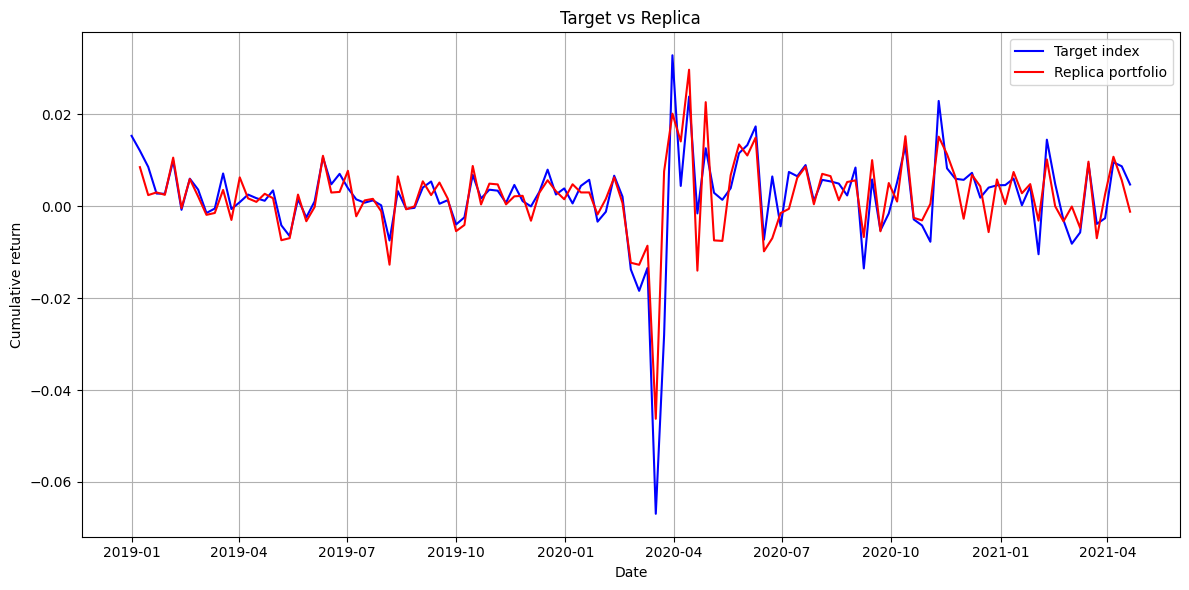

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(Y_test, label='Target index', color='blue')
plt.plot(Y_pred_test, label='Replica portfolio', color='red')
plt.title('Target vs Replica')
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

--------------------

Implementazione modello Ridge

Sweep su alpha

In [25]:
from sklearn.linear_model import Ridge

results = {}

for alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]:
    preds = []

    for i in range(len(X_train_scaled) - rolling_window - 1):
        X_window = X_train_scaled[i : i + rolling_window]
        Y_window = Y_train.iloc[i : i + rolling_window]

        model = Ridge(alpha=alpha, fit_intercept=False)
        model.fit(X_window, Y_window)

        next_X = X_train_scaled[i + rolling_window].reshape(1, -1)
        preds.append(model.predict(next_X)[0])

    y_true = Y_train.iloc[rolling_window : -1]
    te = np.std(y_true - preds)

    results[alpha] = te

best_alpha = min(results, key=results.get)
print(f"Best alpha: {best_alpha}")

Best alpha: 10


In [23]:
import numpy as np
from sklearn.linear_model import LinearRegression

rolling_window = 52

predicted_returns_train_ridge = []
weights_train_ridge = []
dates_train_ridge = []

for i in range(len(X_train_scaled) - rolling_window - 1):

    X_window = X_train_scaled[i : i + rolling_window]
    Y_window = Y_train.iloc[i : i + rolling_window]

    model = Ridge(alpha=best_alpha, fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_train_scaled[i + rolling_window].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_train_ridge.append(pred)
    weights_train_ridge.append(model.coef_)
    dates_train_ridge.append(Y_train.index[i + rolling_window])

X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
Y_all = pd.concat([Y_train, Y_test])

predicted_returns_test_ridge = []
weights_test_ridge           = []
dates_test_ridge             = []

for j in range(len(X_train_scaled), len(X_all_scaled) - 1):

    X_window = X_all_scaled[j - rolling_window : j]
    Y_window = Y_all.iloc[j - rolling_window : j]

    model = Ridge(alpha=best_alpha, fit_intercept=False)
    model.fit(X_window, Y_window)

    next_X = X_all_scaled[j + 1].reshape(1, -1)
    pred = model.predict(next_X)[0]

    predicted_returns_test_ridge.append(pred)
    weights_test_ridge.append(model.coef_)
    dates_test_ridge.append(Y_all.index[j + 1])

Y_pred_train_ridge = pd.Series(predicted_returns_train_ridge, index=dates_train_ridge)
Y_pred_test_ridge = pd.Series(predicted_returns_test_ridge, index=dates_test_ridge)

In [28]:
Y_test_aligned = Y_test.loc[Y_pred_test_ridge.index]
    
metrics = pd.DataFrame({
    'Metric' : ['Annualized return', 
                'Annualized volatility', 
                'Sharpe ratio',
                'Max Drawdown', 
                'Tracking Error Volatility', 
                'Gross Exposure',
                'Information Ratio',
                'Correlation',
                ],
    'Target' : [annual_return(Y_test_aligned) * 100, 
                volatility(Y_test_aligned) * 100, 
                sharpe_ratio(Y_test_aligned),
                max_drawdown(Y_test_aligned) * 100,
                'N/A',
                'N/A',
                'N/A',
                'N/A'],
    'Replica': [annual_return(Y_pred_test_ridge) * 100, 
                volatility(Y_pred_test_ridge) * 100, 
                sharpe_ratio(Y_pred_test_ridge),
                max_drawdown(Y_pred_test_ridge) * 100,
                tracking_error_volatility(Y_pred_test_ridge, Y_test_aligned) * 100,
                gross_exposure(weights_test_ridge),
                information_ratio(Y_pred_test_ridge, Y_test_aligned),
                correlation(Y_pred_test_ridge, Y_test_aligned)]
})

metrics


,Metric,Target,Replica
0,Annualized return,10.503073,7.122618
1,Annualized volatility,7.148066,5.048080
2,Sharpe ratio,1.469359,1.410956
3,Max Drawdown,-13.388949,-6.506067
4,Tracking Error Volatility,N/A,4.628462
5,Gross Exposure,N/A,0.012459
6,Information Ratio,N/A,-0.730362
7,Correlation,N/A,0.764262


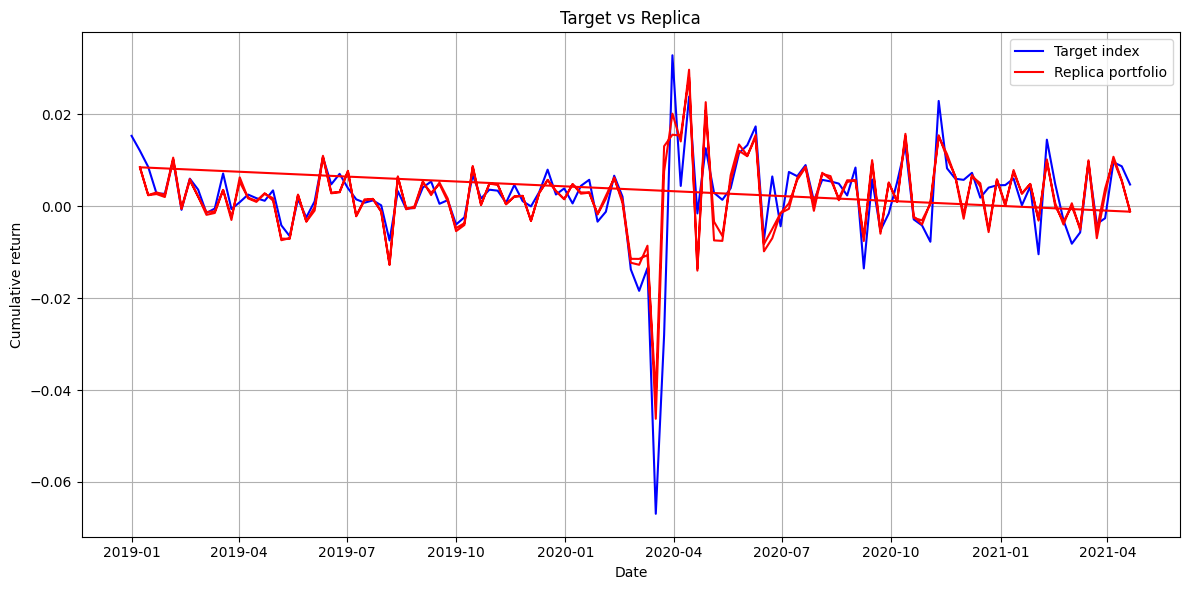

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(Y_test, label='Target index', color='blue')
plt.plot(Y_pred_test_ridge, label='Replica portfolio', color='red')
plt.title('Target vs Replica')
plt.xlabel('Date')
plt.ylabel('Cumulative return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()